<a href="https://colab.research.google.com/github/mritunjay29-ai/Namekart-Domain-Name-Evaluation/blob/main/FINALLLLLLLLLLLL_end_user_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

pandeym29_pricessssss_path = kagglehub.dataset_download('pandeym29/pricessssss')
pandeym29_new_endprice_path = kagglehub.dataset_download('pandeym29/new-endprice')

print('Data source import complete.')


# BIG DATA end user price (kaggle - mritunjayp.tt.21@nitj.ac.in)

In [ ]:
# ------------------ Imports ------------------
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

# ------------------ Load Dataset ------------------
df = pd.read_csv("/kaggle/input/new-endprice/end_user_price.csv")
df['text_input'] = df[['words', 'suffix', 'category', 'whois_registrar']].astype(str).agg(' '.join, axis=1)

# ------------------ Feature Engineering ------------------
df['vowel_ratio'] = df['Vowels'] / df['Letters'].replace(0, 1)
df['letter_density'] = df['Letters'] / df['Length'].replace(0, 1)
df['cpc_ratio'] = df['search_cpc_exact_term'] / df['search_cpc_broad_term'].replace(0, 1)
df['volume_ratio'] = df['search_volume_exact_term'] / df['search_volume_broad_term'].replace(0, 1)
df['wayback_density'] = df['wayback_records'] / df['wayback_age'].replace(0, 1)
df['is_common_suffix'] = df['suffix'].isin(['com', 'net', 'org']).astype(int)

numerical_columns = [
    'suffix_score', 'extensions_taken', 'search_ad_competition_broad_term',
    'search_ad_competition_exact_term', 'search_cpc_broad_term', 'search_cpc_exact_term',
    'search_results_sld', 'search_results_term', 'search_volume_broad_term', 'search_volume_exact_term',
    'tld_count', 'wayback_age', 'wayback_records', 'whois_age', 'age_yr', 'Length',
    'Special_chars', 'Letters', 'Upper_case', 'Lower_case', 'Vowels', 'Consonants', 'Numbers',
    'word_ratio', 'pronounceability_score', 'appraised_wholesale_value',
    'vowel_ratio', 'letter_density', 'cpc_ratio', 'volume_ratio', 'wayback_density', 'is_common_suffix'
]

# ------------------ Scaling ------------------
scaler = StandardScaler()
numerical_features = scaler.fit_transform(df[numerical_columns])

label_scaler = StandardScaler()
log_labels = np.log1p(df['price'].values.reshape(-1, 1))
labels_scaled = label_scaler.fit_transform(log_labels)

# ------------------ Train-Test Split ------------------
X_text = df['text_input']
X_num_train, X_num_val, X_text_train, X_text_val, y_train, y_val = train_test_split(
    numerical_features, X_text, labels_scaled, test_size=0.2, random_state=42
)

# ------------------ Tokenizer ------------------
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# ------------------ Dataset Class ------------------
class DomainDataset(Dataset):
    def __init__(self, texts, num_features, labels):
        self.encodings = tokenizer(texts.tolist(), padding=True, truncation=True, max_length=50, return_tensors="pt")
        self.num_features = torch.tensor(num_features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'numerical': self.num_features[idx],
            'label': self.labels[idx]
        }

# ------------------ Attention Pooling ------------------
class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(input_dim))

    def forward(self, x):
        weights = torch.matmul(x, self.query)
        weights = torch.softmax(weights, dim=1).unsqueeze(-1)
        return torch.sum(weights * x, dim=1)

# ------------------ Text Encoder ------------------
class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("distilbert-base-uncased")
        self.norm = nn.LayerNorm(768)
        self.pool = AttentionPooling(768)
        self.text_fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = self.norm(x)
        x = self.pool(x)
        return self.text_fc(x)

# ------------------ Numerical Encoder ------------------
class NumericalFeatureNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.model(x)

# ------------------ Fusion Model ------------------
class DomainPricePredictionModel(nn.Module):
    def __init__(self, num_dim):
        super().__init__()
        self.text_encoder = TextEncoder()
        self.num_encoder = NumericalFeatureNN(num_dim)
        self.fusion_fc1 = nn.Linear(256 + 128, 128)
        self.fusion_fc2 = nn.Linear(128, 64)
        self.output_head = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, num):
        text_embed = self.text_encoder(input_ids, attention_mask)
        num_embed = self.num_encoder(num)
        x = torch.cat((text_embed, num_embed), dim=1)
        x = self.relu(self.fusion_fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fusion_fc2(x))
        return self.output_head(x)

# ------------------ Training Setup ------------------
train_dataset = DomainDataset(X_text_train, X_num_train, y_train)
val_dataset = DomainDataset(X_text_val, X_num_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DomainPricePredictionModel(num_dim=X_num_train.shape[1]).to(device)
criterion = nn.HuberLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

2025-05-30 04:32:29.362106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748579549.779150      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748579549.909156      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# ------------------ Training Loop ------------------
for epoch in range(6):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        num_inputs = batch['numerical'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        output = model(input_ids, attention_mask, num_inputs)
        output = torch.clamp(output, min=-5, max=5)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}, Train Loss: {train_loss / len(train_loader):.4f}")

100%|██████████| 8139/8139 [31:51<00:00,  4.26it/s]


Epoch 1, Train Loss: 0.0509


100%|██████████| 8139/8139 [30:18<00:00,  4.48it/s]


Epoch 2, Train Loss: 0.0355


100%|██████████| 8139/8139 [30:18<00:00,  4.48it/s]


...

Epoch 4, Train Loss: 0.0292


100%|██████████| 8139/8139 [30:16<00:00,  4.48it/s]


Epoch 5, Train Loss: 0.0278


100%|██████████| 8139/8139 [30:16<00:00,  4.48it/s]

Epoch 6, Train Loss: 0.0278


In [ ]:
# ------------------ Evaluation ------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        num_inputs = batch['numerical'].to(device)
        labels = batch['label'].to(device)
        output = model(input_ids, attention_mask, num_inputs)
        output = torch.clamp(output, min=-5, max=5)
        y_true.append(labels.cpu().numpy())
        y_pred.append(output.cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_true_log = label_scaler.inverse_transform(y_true)
y_pred_log = label_scaler.inverse_transform(y_pred)
true_price = np.expm1(y_true_log)
preds_price = np.expm1(y_pred_log)

mae = mean_absolute_error(true_price, preds_price)
rmse = np.sqrt(mean_squared_error(true_price, preds_price))

print(f"\n MAE: {mae:.2f}, RMSE: {rmse:.2f}")


 MAE: 161.50, RMSE: 751.87


In [ ]:
r2 = r2_score(true_price, preds_price)
print(r2)

0.8416648779044313


In [ ]:
print(f"True price range: {true_price.min():,.2f} to {true_price.max():,.2f}")
print(f"Predicted price range: {preds_price.min():,.2f} to {preds_price.max():,.2f}")

True price range: 210.00 to 121,999.98
Predicted price range: 263.66 to 31,999.74


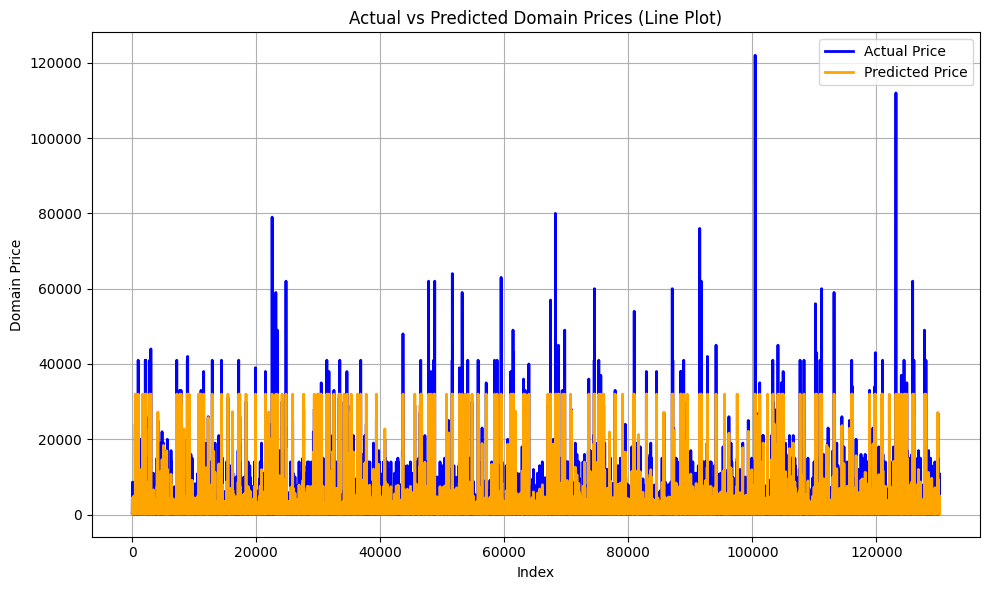

In [ ]:
# ------------------ Visualization ------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(true_price.flatten(), label="Actual Price", color='blue', linewidth=2)

plt.plot(preds_price.flatten(), label="Predicted Price", color='orange', linewidth=2)

plt.xlabel("Index")
plt.ylabel("Domain Price")
plt.title("Actual vs Predicted Domain Prices (Line Plot)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

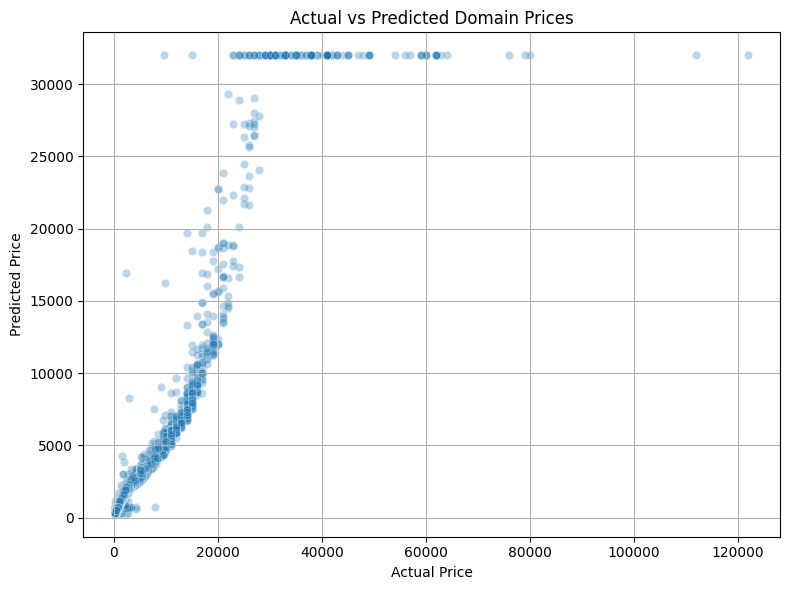

In [ ]:
# ------------------ Visualization ------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=true_price.flatten(), y=preds_price.flatten(), alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Domain Prices")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save model weights
torch.save(model.state_dict(), "hybrid_transformer_mlp_model.pt")

# Save scalers
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(label_scaler, "label_scaler.pkl")

# After labels_scaled is created during training
label_min = labels_scaled.min()
label_max = labels_scaled.max()
joblib.dump((label_min, label_max), "label_range.pkl")

['label_range.pkl']

In [ ]:
# ------------------ DOMAIN INPUT ------------------
domain_data = {
    "domain": "name.ai",
    "category": "Other -- Generic 4-letter",
    "words": "name",
    "suffix": "ai",
    "whois_registrar": "NETHERLANDS DOMAINS",
    "priority_score": 1,
    "suffix_score": 1,
    "extensions_taken": 4,
    "search_ad_competition_broad_term": 3,  # "high" → 3
    "search_ad_competition_exact_term": 3,  # "high" → 3
    "search_cpc_broad_term": 1.46,
    "search_cpc_exact_term": 1.46,
    "search_results_sld": 1e8,
    "search_results_term": 1e8,
    "search_volume_broad_term": 3375000,
    "search_volume_exact_term": 168750,
    "tld_count": 4,  # com/net/org/biz taken
    "wayback_age": 0,  # -1 given → default to 0
    "wayback_records": 0,  # -1 given → default to 0
    "whois_age": 2690,  # in days
    "age_yr": round(2690 / 365.25, 2),  # ≈ 7.36 years
    "Length": 4,
    "Special_chars": 0,
    "Letters": 4,
    "Upper_case": 0,
    "Lower_case": 4,
    "Vowels": 2,  # a, e
    "Consonants": 2,  # n, m
    "Numbers": 0,
    "word_ratio": 1,  # 1 real word
    "pronounceability_score": 0.0,
    "appraised_wholesale_value": 3000
}

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import joblib

# ------------------ DataFrame & Feature Engineering ------------------
df = pd.DataFrame([domain_data])
df['text_input'] = df[['words', 'suffix', 'category', 'whois_registrar']].astype(str).agg(' '.join, axis=1)
df['vowel_ratio'] = df['Vowels'] / df['Letters'].replace(0, 1)
df['letter_density'] = df['Letters'] / df['Length'].replace(0, 1)
df['cpc_ratio'] = df['search_cpc_exact_term'] / df['search_cpc_broad_term'].replace(0, 1)
df['volume_ratio'] = df['search_volume_exact_term'] / df['search_volume_broad_term'].replace(0, 1)
df['wayback_density'] = df['wayback_records'] / df['wayback_age'].replace(0, 1)
df['is_common_suffix'] = df['suffix'].isin(['com', 'net', 'org','ai']).astype(int)

# ------------------ Feature List ------------------
numerical_columns = [
    'suffix_score', 'extensions_taken', 'search_ad_competition_broad_term',
    'search_ad_competition_exact_term', 'search_cpc_broad_term', 'search_cpc_exact_term',
    'search_results_sld', 'search_results_term', 'search_volume_broad_term', 'search_volume_exact_term',
    'tld_count', 'wayback_age', 'wayback_records', 'whois_age', 'age_yr', 'Length',
    'Special_chars', 'Letters', 'Upper_case', 'Lower_case', 'Vowels', 'Consonants', 'Numbers',
    'word_ratio', 'pronounceability_score', 'appraised_wholesale_value',
    'vowel_ratio', 'letter_density', 'cpc_ratio', 'volume_ratio', 'wayback_density', 'is_common_suffix'
]

# ------------------ Load Tokenizer & Scalers ------------------
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
scaler = joblib.load("feature_scaler.pkl")
label_scaler = joblib.load("label_scaler.pkl")
label_min, label_max = joblib.load("label_range.pkl")  # from earlier step

# ------------------ Process Inputs ------------------
numerical_features = scaler.transform(df[numerical_columns])
encodings = tokenizer(df['text_input'].tolist(), padding=True, truncation=True, max_length=50, return_tensors="pt")

input_ids = encodings['input_ids']
attention_mask = encodings['attention_mask']
num_tensor = torch.tensor(numerical_features, dtype=torch.float32)

# ------------------ Load Model ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(input_dim))
    def forward(self, x):
        weights = torch.matmul(x, self.query)
        weights = torch.softmax(weights, dim=1).unsqueeze(-1)
        return torch.sum(weights * x, dim=1)

class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("distilbert-base-uncased")
        self.norm = nn.LayerNorm(768)
        self.pool = AttentionPooling(768)
        self.text_fc = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.2))
    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = self.norm(x)
        x = self.pool(x)
        return self.text_fc(x)

class NumericalFeatureNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    def forward(self, x): return self.model(x)

class DomainPricePredictionModel(nn.Module):
    def __init__(self, num_dim):
        super().__init__()
        self.text_encoder = TextEncoder()
        self.num_encoder = NumericalFeatureNN(num_dim)
        self.fusion_fc1 = nn.Linear(256 + 128, 128)
        self.fusion_fc2 = nn.Linear(128, 64)
        self.output_head = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    def forward(self, input_ids, attention_mask, num):
        text_embed = self.text_encoder(input_ids, attention_mask)
        num_embed = self.num_encoder(num)
        x = torch.cat((text_embed, num_embed), dim=1)
        x = self.relu(self.fusion_fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fusion_fc2(x))
        return self.output_head(x)

# Instantiate and load weights
model = DomainPricePredictionModel(num_dim=numerical_features.shape[1]).to(device)
model.load_state_dict(torch.load("hybrid_transformer_mlp_model.pt", map_location=device), strict=False)
model.eval()

# ------------------ Predict ------------------
with torch.no_grad():
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    num_tensor = num_tensor.to(device)

    pred = model(input_ids, attention_mask, num_tensor)
    pred = torch.clamp(pred, min=label_min, max=label_max)
    pred_log = label_scaler.inverse_transform(pred.cpu().numpy())
    pred_price = np.expm1(np.clip(pred_log, a_min=0, a_max=15)).flatten()[0]

# ------------------ Output ------------------
print(f" Predicted price for {domain_data['domain']}: ${pred_price:,.2f}")

 Predicted price for name.ai: $165,999.94
